<a href="https://colab.research.google.com/github/caotuuyen/KLTN/blob/main/KLTN_11226802.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [112]:
# --- 1. IMPORT CÁC THƯ VIỆN CẦN THIẾT ---
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Sklearn Modules
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score
)

# XGBoost
from xgboost import XGBClassifier

In [113]:
# --- 2. THU THẬP DỮ LIỆU ---
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_excel('/content/drive/MyDrive/KLTN.xlsx')
print("Dữ liệu đã được import thành công!")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dữ liệu đã được import thành công!


,year,customer_id,phone_no,gender,age,no_of_days_subscribed,multi_screen,mail_subscribed,weekly_mins_watched,minimum_daily_mins,maximum_daily_mins,weekly_max_night_mins,videos_watched,maximum_days_inactive,customer_support_calls,churn
0,2020,100198,409-8743,Female,36,62,no,no,148.35,12.2,16.81,82,1,4.0,1,0.0
1,2020,100643,340-5930,Female,39,149,no,no,294.45,7.7,33.37,87,3,3.0,2,0.0
2,2020,100756,372-3750,Female,65,126,no,no,87.30,11.9,9.89,91,1,4.0,5,1.0
3,2020,101595,331-4902,Female,24,131,no,yes,321.30,9.5,36.41,102,4,3.0,3,0.0
4,2020,101653,351-8398,Female,40,191,no,no,243.00,10.9,27.54,83,7,3.0,1,0.0


In [114]:
# --- 3. TIỀN XỬ LÝ DỮ LIỆU & LÀM SẠCH ---

# 3.1. Loại bỏ các cột không cần thiết cho mô hình
df.drop(['customer_id', 'year', 'phone_no'], axis=1, inplace=True, errors='ignore')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   gender                  1976 non-null   object 
 1   age                     2000 non-null   int64  
 2   no_of_days_subscribed   2000 non-null   int64  
 3   multi_screen            2000 non-null   object 
 4   mail_subscribed         2000 non-null   object 
 5   weekly_mins_watched     2000 non-null   float64
 6   minimum_daily_mins      2000 non-null   float64
 7   maximum_daily_mins      2000 non-null   float64
 8   weekly_max_night_mins   2000 non-null   int64  
 9   videos_watched          2000 non-null   int64  
 10  maximum_days_inactive   1972 non-null   float64
 11  customer_support_calls  2000 non-null   int64  
 12  churn                   1965 non-null   float64
dtypes: float64(5), int64(5), object(3)
memory usage: 203.3+ KB


In [115]:
# 3.2. Xử lý giá trị khuyết (fillna)
print("\nKiểm tra giá trị khuyết trước khi xử lý:")
null_df = df.isnull().sum().to_frame(name='Số lượng khuyết')
null_df


Kiểm tra giá trị khuyết trước khi xử lý:


,Số lượng khuyết
gender,24
age,0
no_of_days_subscribed,0
multi_screen,0
mail_subscribed,0
weekly_mins_watched,0
minimum_daily_mins,0
maximum_daily_mins,0
weekly_max_night_mins,0
videos_watched,0


In [116]:
# DROP các dòng thiếu nhãn mục tiêu
df.dropna(subset=['churn'], inplace=True)
# Ép kiểu churn về int sau khi xử lý khuyết
df['churn'] = df['churn'].astype(int)

print("\nKiểm tra giá trị khuyết sau khi xử lý:")
null_df = df.isnull().sum().to_frame(name='Số lượng khuyết')
null_df


Kiểm tra giá trị khuyết sau khi xử lý:


,Số lượng khuyết
gender,24
age,0
no_of_days_subscribed,0
multi_screen,0
mail_subscribed,0
weekly_mins_watched,0
minimum_daily_mins,0
maximum_daily_mins,0
weekly_max_night_mins,0
videos_watched,0


In [117]:
# 3.3. FEATURE ENGINEERING: TẠO BIẾN TỶ LỆ

# 1. Calls_per_min: Tần suất gọi hỗ trợ trên mỗi phút xem hàng tuần
# Ý nghĩa: Đo lường mức độ 'phiền toái' hoặc sự thất vọng của khách hàng.
# Một khách hàng xem ít (mẫu số nhỏ) mà gọi hỗ trợ nhiều (tử số lớn) có nguy cơ Churn cao hơn.
# Xử lý: Tránh chia cho 0 bằng cách thay thế các giá trị weekly_mins_watched = 0 bằng 1 (hoặc một giá trị dương rất nhỏ) để đảm bảo phép tính hợp lệ.
df['weekly_mins_watched_safe'] = df['weekly_mins_watched'].replace(0, 1)
df['calls_per_min'] = df['customer_support_calls'] / df['weekly_mins_watched_safe']

# 2. Avg_daily_watch_time: Số phút xem trung bình hàng ngày (để đánh giá tính ổn định)
# Ý nghĩa: Khoảng cách giữa Max và Min daily mins thể hiện sự bất ổn định trong thói quen.
df['daily_min_max_diff'] = df['maximum_daily_mins'] - df['minimum_daily_mins']

# 3. Churn_Risk_Score (Tổng hợp chỉ báo rủi ro)
# Ý nghĩa: Tổng hợp các yếu tố hành vi mang tính rủi ro cao.
df['behavioral_risk_score'] = df['customer_support_calls'] + df['maximum_days_inactive']

# Loại bỏ cột an toàn đã tạo ra
df.drop('weekly_mins_watched_safe', axis=1, inplace=True)
print("\nĐã tạo các biến Feature Engineering mới: calls_per_min, daily_min_max_diff, behavioral_risk_score")



Đã tạo các biến Feature Engineering mới: calls_per_min, daily_min_max_diff, behavioral_risk_score


In [118]:
# 3.4. Tách biến độc lập (X) và biến mục tiêu (Y)
X = df.drop("churn", axis=1)
Y = df["churn"]

In [119]:
# 3.5. CHIA TRAIN/TEST (Bước quan trọng nhất - Phải làm trước)
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.3,
    random_state=42,
    stratify=Y
)
print(f"\nĐã chia Train/Test. Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")


Đã chia Train/Test. Train: 1375, Test: 590


In [120]:
# 4. PHÂN TÍCH DỮ LIỆU KHÁM PHÁ (EDA) - CHỈ TRÊN TẬP TRAIN***
print("\n--- Bắt đầu EDA (chỉ trên tập Train) ---")
# Để thực hiện EDA, ta kết hợp X_train và Y_train
df_train = X_train.copy()
df_train['churn'] = Y_train


--- Bắt đầu EDA (chỉ trên tập Train) ---



Phân bố biến mục tiêu:
Non-Churn (0): 1192 (86.69%)
Churn (1): 183 (13.31%)


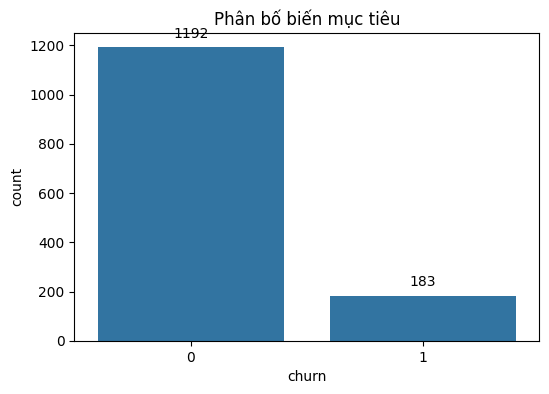

In [121]:
# 4.1. Kiểm tra sự mất cân bằng dữ liệu
print("\nPhân bố biến mục tiêu:")
churn_counts = Y_train.value_counts()
churn_ratios = Y_train.value_counts(normalize=True)
print(f"Non-Churn (0): {churn_counts[0]} ({churn_ratios[0]:.2%})")
print(f"Churn (1): {churn_counts[1]} ({churn_ratios[1]:.2%})")
plt.figure(figsize=(6, 4))
sns.countplot(x=Y_train)
plt.title('Phân bố biến mục tiêu')
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                       ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')
plt.show()

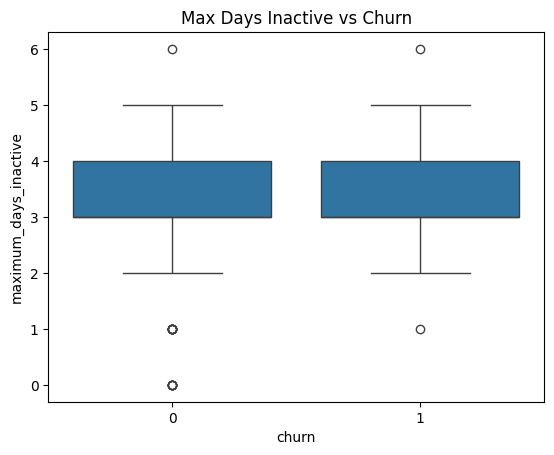

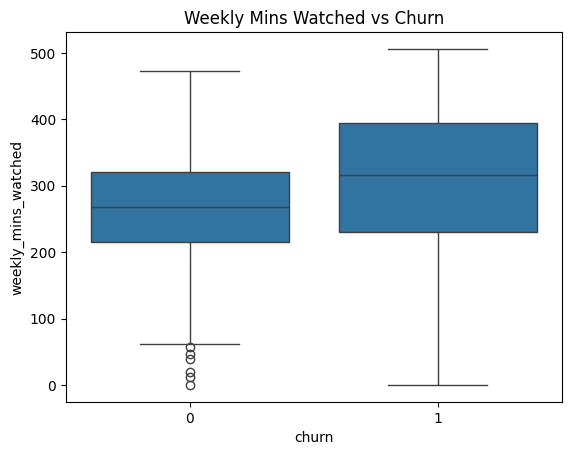

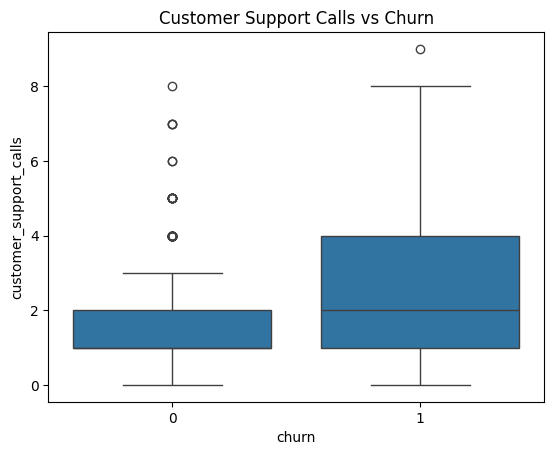

In [122]:
# 4.2. Boxplot so sánh hành vi (trên tập Train)
# Biến 1: maximum_days_inactive
sns.boxplot(x='churn', y='maximum_days_inactive', data=df_train)
plt.title('Max Days Inactive vs Churn')
plt.show()
# Biến 2: weekly_mins_watched
sns.boxplot(x='churn', y='weekly_mins_watched', data=df_train)
plt.title('Weekly Mins Watched vs Churn')
plt.show()
# Biến 3: customer_support_calls
sns.boxplot(x='churn', y='customer_support_calls', data=df_train)
plt.title('Customer Support Calls vs Churn')
plt.show()


Trực quan hóa Boxplot cho các biến Feature Engineering mới:


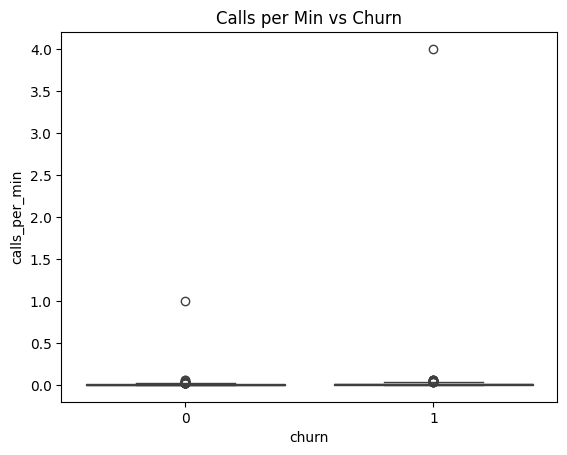

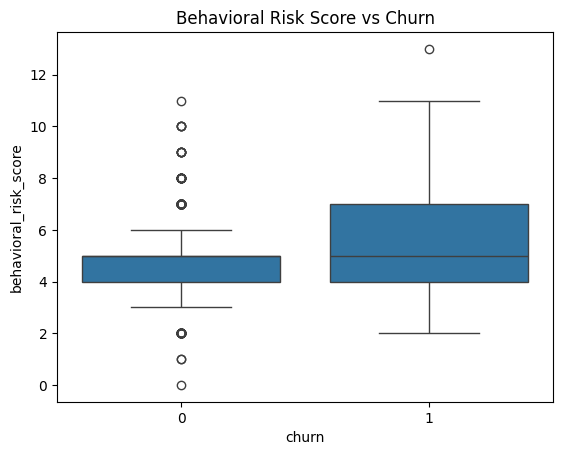

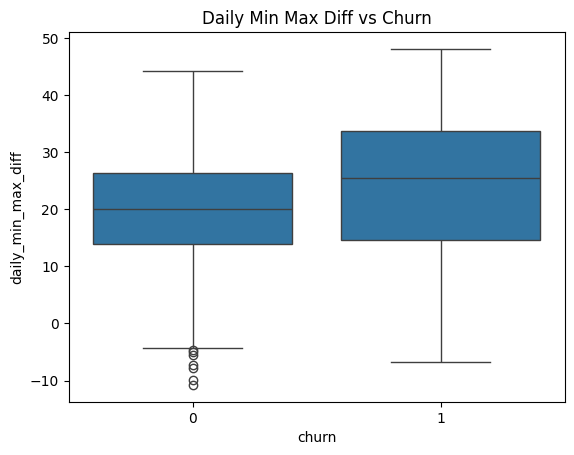

In [123]:
# 4.2.2. Boxplot so sánh hành vi (trên tập Train) (Tiếp tục với biến mới)

print("\nTrực quan hóa Boxplot cho các biến Feature Engineering mới:")
# Biến mới 1: calls_per_min
sns.boxplot(x='churn', y='calls_per_min', data=df_train)
plt.title('Calls per Min vs Churn')
plt.show()

# Biến mới 2: behavioral_risk_score
sns.boxplot(x='churn', y='behavioral_risk_score', data=df_train)
plt.title('Behavioral Risk Score vs Churn')
plt.show()

# Biến mới 3: daily_min_max_diff
sns.boxplot(x='churn', y='daily_min_max_diff', data=df_train)
plt.title('Daily Min Max Diff vs Churn')
plt.show()

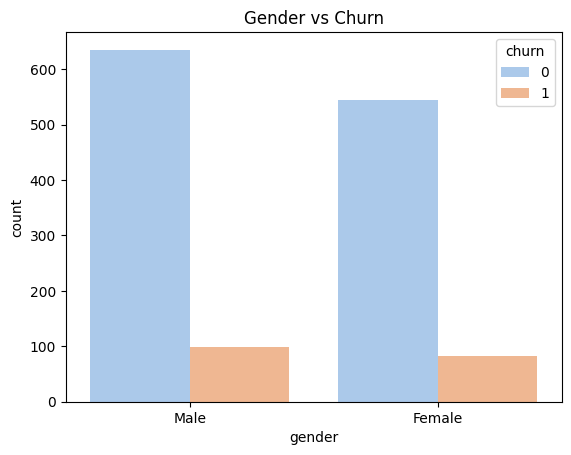

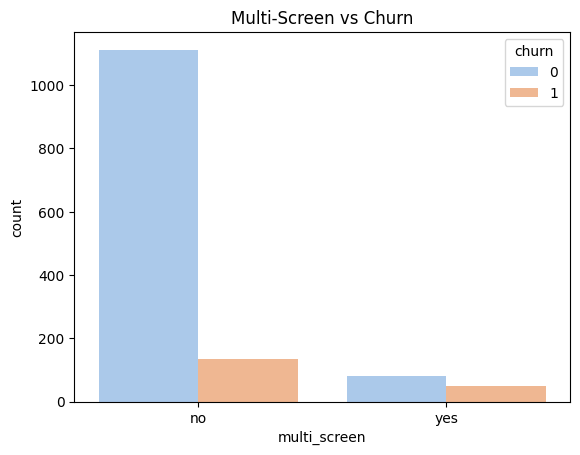

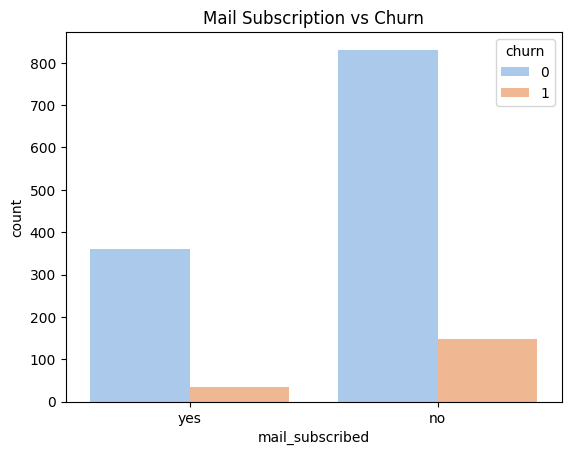

In [124]:
# 4.3. Countplot so sánh biến phân loại (trên tập Train)
# Biến 1: gender
sns.countplot(x='gender', hue='churn', data=df_train, palette='pastel', hue_order=[0,1])
plt.title('Gender vs Churn')
plt.show()
# Biến 2: multi_screen
sns.countplot(x='multi_screen', hue='churn', data=df_train, palette='pastel', hue_order=[0,1])
plt.title('Multi-Screen vs Churn')
plt.show()
# Biến 3: mail_subscribed
sns.countplot(x='mail_subscribed', hue='churn', data=df_train, palette='pastel', hue_order=[0,1])
plt.title('Mail Subscription vs Churn')
plt.show()

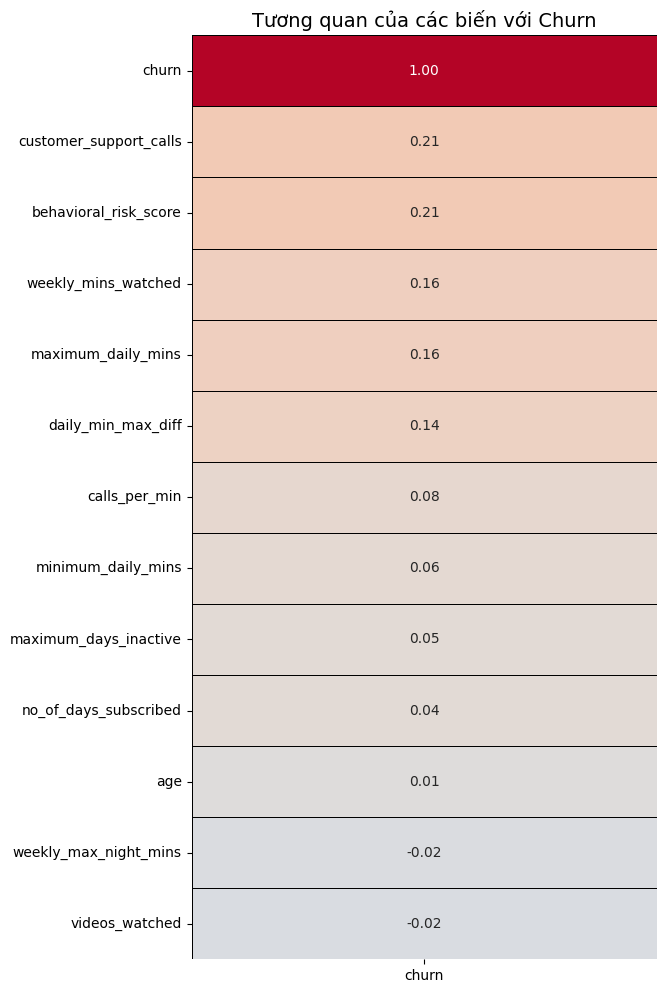

--- Kết thúc EDA ---


In [125]:
# 4.4. Trực quan hóa Tương quan (trên tập Train)
plt.figure(figsize=(6, 12))
# Tính tương quan Point-Biserial (vì 'churn' là nhị phân)
try:
    corr_with_churn = df_train.corr(numeric_only=True)['churn'].sort_values(ascending=False).to_frame()
    sns.heatmap(corr_with_churn, annot=True, cmap='coolwarm', fmt=".2f", center=0, cbar=False, linewidths=0.5, linecolor='black')
    plt.title('Tương quan của các biến với Churn', fontsize=14)
    plt.show()
except Exception as e:
    print(f"Lỗi khi vẽ heatmap: {e}")

print("--- Kết thúc EDA ---")

In [126]:
# --- 5. ĐỊNH NGHĨA PIPELINE TIỀN XỬ LÝ (CHIẾN LƯỢC MỚI) ---
# 5.1. Xác định các nhóm cột
numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(include='object').columns.tolist()

print(f"\nCột số: {numerical_features}")
print(f"Cột phân loại: {categorical_features}")

# 5.2. Xây dựng các bước xử lý

# Transformer cho biến phân loại (Dùng chung)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Transformer cho biến số - CÓ Scaling (Cho Logistic Regression)
numeric_transformer_scaled = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Transformer cho biến số - KHÔNG Scaling (Cho Tree-based: RF, XGB)
numeric_transformer_unscaled = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# 5.3. Tạo 2 bộ Preprocessor riêng biệt

# Bộ 1: Cho Linear Model (Cần Scale)
preprocessor_linear = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_scaled, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

# Bộ 2: Cho Tree Model (Không cần Scale - Giữ nguyên bản chất dữ liệu)
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_unscaled, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)


Cột số: ['age', 'no_of_days_subscribed', 'weekly_mins_watched', 'minimum_daily_mins', 'maximum_daily_mins', 'weekly_max_night_mins', 'videos_watched', 'maximum_days_inactive', 'customer_support_calls', 'calls_per_min', 'daily_min_max_diff', 'behavioral_risk_score']
Cột phân loại: ['gender', 'multi_screen', 'mail_subscribed']


In [127]:
# --- 6. XÂY DỰNG, TỐI ƯU & ĐÁNH GIÁ MÔ HÌNH (OPTIMIZED) ---
results = []
# Định nghĩa hàm huấn luyện chung để tránh lặp code
def train_and_evaluate(model_name, model_obj, preprocessor, param_grid):
    print(f"\n{'='*10} Đang huấn luyện: {model_name} {'='*10}")

    # 1. Tạo Pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model_obj)
    ])

    # 2. GridSearch với Metric tối ưu là 'f1' (Cân bằng Precision/Recall)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    grid = GridSearchCV(
        pipeline,
        param_grid=param_grid,
        cv=cv,
        scoring='f1',
        n_jobs=-1
    )

    grid.fit(X_train, Y_train)

    # 3. Đánh giá trên Test Set
    best_model = grid.best_estimator_
    Y_pred = best_model.predict(X_test)

    # Lấy xác suất an toàn
    try:
        if hasattr(best_model, "predict_proba"):
            Y_prob = best_model.predict_proba(X_test)[:, 1]
        else:
            Y_prob = best_model.decision_function(X_test)
        roc_auc = roc_auc_score(Y_test, Y_prob)
    except:
        roc_auc = np.nan

    # 4. Lưu kết quả
    acc = accuracy_score(Y_test, Y_pred)
    rec = recall_score(Y_test, Y_pred)
    prec = precision_score(Y_test, Y_pred)
    f1 = f1_score(Y_test, Y_pred)

    results.append({
        'Model': model_name,
        'Accuracy': round(acc * 100, 2),
        'Recall (Churn)': round(rec * 100, 2),
        'Precision (Churn)': round(prec * 100, 2),
        'F1-Score (Churn)': round(f1 * 100, 2),
        'ROC-AUC': round(roc_auc * 100, 2)
    })

    print(f"Best Params: {grid.best_params_}")
    print("Classification Report:")
    print(classification_report(Y_test, Y_pred))

    # Vẽ Confusion Matrix
    plt.figure(figsize=(4, 3))
    sns.heatmap(confusion_matrix(Y_test, Y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()
     # ***MỚI***: Thêm lại phần vẽ ROC riêng lẻ
    if not np.isnan(roc_auc):
        fpr, tpr, thresholds = roc_curve(Y_test, Y_prob)
        plt.figure(figsize=(6,4))
        plt.plot(fpr, tpr, lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0,1],[0,1], linestyle='--', color='grey', label='Đoán ngẫu nhiên')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC curve - {model_name}')
        plt.legend(loc='lower right')
        plt.grid()
        plt.show()

    return best_model


========== Đang huấn luyện: Logistic Regression ==========
Best Params: {'model__C': 10}
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.73      0.83       511
           1       0.32      0.81      0.46        79

    accuracy                           0.74       590
   macro avg       0.64      0.77      0.64       590
weighted avg       0.88      0.74      0.78       590



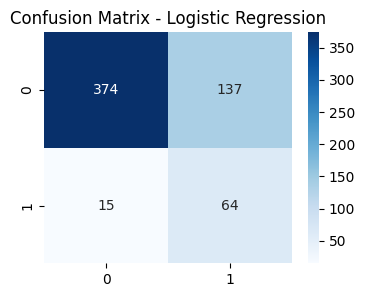

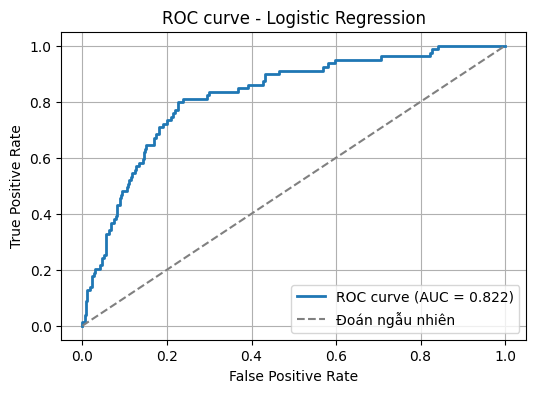

In [128]:
# === 6.1. Logistic Regression (Dùng preprocessor_linear) ===
param_log = {'model__C': [0.01, 0.1, 1, 10]}
best_logreg_model = train_and_evaluate(
    "Logistic Regression",
    LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    preprocessor_linear, # <--- Dùng bộ có Scale
    param_log
)


--- ODDS RATIO (Tỷ số Odds) - Logistic Regression ---
                   Feature  Coefficient  Odds_Ratio
15        multi_screen_yes     1.058559    2.882216
9            calls_per_min     0.937228    2.552896
11   behavioral_risk_score     0.478207    1.613179
16      mail_subscribed_no     0.453891    1.574426
8   customer_support_calls     0.274363    1.315692
2      weekly_mins_watched     0.265484    1.304062
4       maximum_daily_mins     0.261123    1.298387
3       minimum_daily_mins     0.237575    1.268170
10      daily_min_max_diff     0.179553    1.196682
1    no_of_days_subscribed     0.077394    1.080468
13             gender_Male     0.076191    1.079169
0                      age     0.048730    1.049937
12           gender_Female     0.006060    1.006079
5    weekly_max_night_mins    -0.041703    0.959155
6           videos_watched    -0.045335    0.955678
7    maximum_days_inactive    -0.287193    0.750367
17     mail_subscribed_yes    -0.371640    0.689603
14       

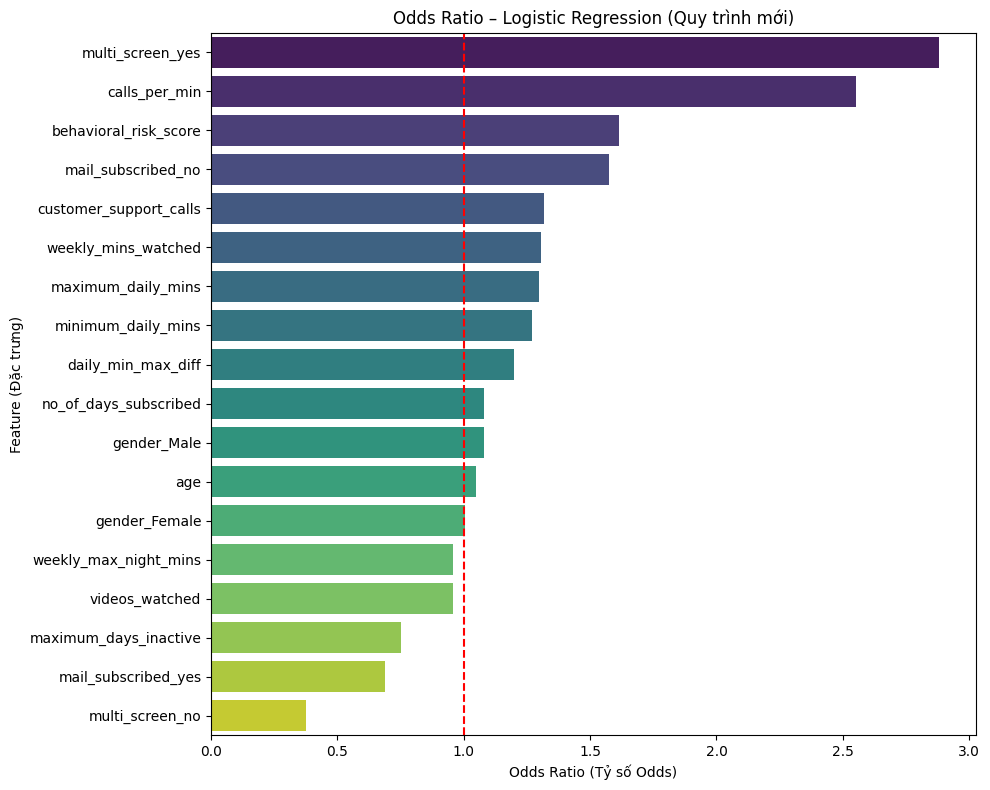

In [129]:
#Odds ratio
print("\n--- ODDS RATIO (Tỷ số Odds) - Logistic Regression ---")
# Lấy tên đặc trưng (tương tự như RF)
preprocessor_fitted_log = best_logreg_model.named_steps['preprocessor']
onehot_cols_log = preprocessor_fitted_log.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
feature_names_log = numerical_features + onehot_cols_log.tolist()

# Lấy hệ số
coefficients = best_logreg_model.named_steps['model'].coef_[0]

logreg_coef = pd.DataFrame({
    "Feature": feature_names_log,
    "Coefficient": coefficients
})
logreg_coef["Odds_Ratio"] = np.exp(logreg_coef["Coefficient"])
logreg_coef_sorted = logreg_coef.sort_values(by="Odds_Ratio", ascending=False)

print(logreg_coef_sorted)

# Vẽ biểu đồ Odds Ratio
plt.figure(figsize=(10, 8))
sns.barplot(
    x="Odds_Ratio",
    y="Feature",
    data=logreg_coef_sorted,
    palette="viridis"
)
plt.axvline(1, color="red", linestyle="--")
plt.title("Odds Ratio – Logistic Regression (Quy trình mới)")
plt.xlabel("Odds Ratio (Tỷ số Odds)")
plt.ylabel("Feature (Đặc trưng)")
plt.tight_layout()
plt.show()


========== Đang huấn luyện: Random Forest ==========
Best Params: {'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.89      0.93       511
           1       0.54      0.80      0.64        79

    accuracy                           0.88       590
   macro avg       0.75      0.85      0.79       590
weighted avg       0.91      0.88      0.89       590



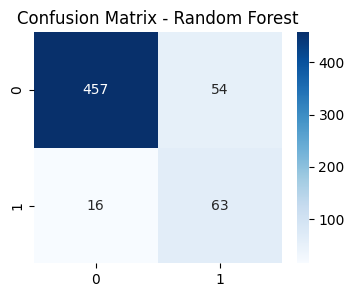

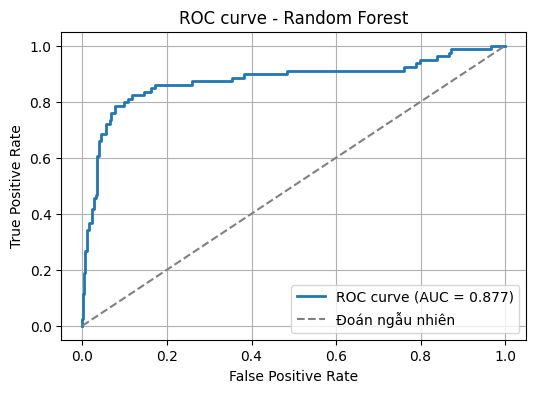

In [130]:
# === 6.2. Random Forest (Dùng preprocessor_tree) ===
param_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10, 15],
    'model__min_samples_leaf': [1, 2]
}
best_rf_model = train_and_evaluate(
    "Random Forest",
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    preprocessor_tree, # <--- Dùng bộ KHÔNG Scale
    param_rf
)


========== Đang huấn luyện: XGBoost ==========
Best Params: {'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__n_estimators': 100}
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       511
           1       0.66      0.68      0.67        79

    accuracy                           0.91       590
   macro avg       0.80      0.81      0.81       590
weighted avg       0.91      0.91      0.91       590



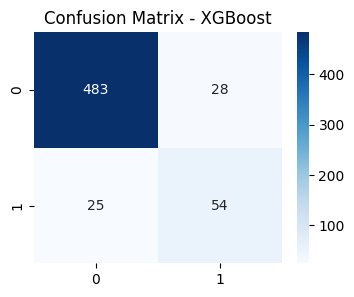

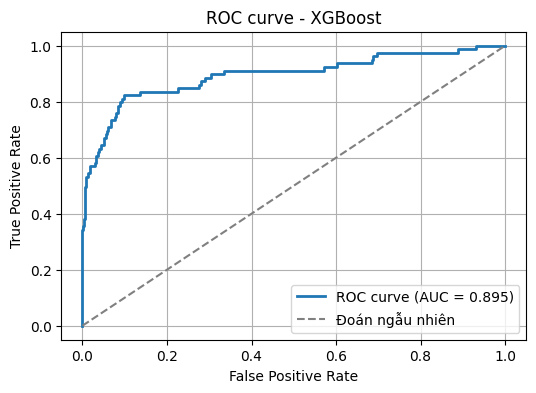

In [131]:
# === 6.3. XGBoost (Dùng preprocessor_tree & Mở rộng tham số) ===
scale_pos_weight = (Y_train == 0).sum() / (Y_train == 1).sum()
param_xgb = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1] # Thêm learning rate
}
best_xgb_model = train_and_evaluate(
    "XGBoost",
    XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss'),
    preprocessor_tree, # <--- Dùng bộ KHÔNG Scale
    param_xgb
)

In [132]:
# --- 7. TỔNG HỢP VÀ SO SÁNH KẾT QUẢ ---
def cross_val_metrics(model, X, Y, model_name):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    recall_scores = cross_val_score(model, X, Y, cv=cv, scoring='recall', n_jobs=-1)
    f1_scores = cross_val_score(model, X, Y, cv=cv, scoring='f1', n_jobs=-1)
    print(f"\n>>> Cross-Validation ({model_name})")
    print(f"Recall trung bình (5-fold): {recall_scores.mean():.3f} ± {recall_scores.std():.3f}")
    print(f"F1-score trung bình (5-fold): {f1_scores.mean():.3f} ± {f1_scores.std():.3f}")
    return

print("\n--- Chạy Cross-Validation trên toàn bộ dữ liệu Train ---")
cross_val_metrics(best_logreg_model, X_train, Y_train, "Logistic Regression (Optimized)")
cross_val_metrics(best_rf_model, X_train, Y_train, "Random Forest (Optimized)")
cross_val_metrics(best_xgb_model, X_train, Y_train, "XGBoost (Optimized)")

results_df = pd.DataFrame(results)
results_df.sort_values(by='F1-Score (Churn)', ascending=False, inplace=True)
print("\n--- BẢNG TỔNG HỢP KẾT QUẢ MÔ HÌNH (TRÊN TẬP TEST) ---")
print(results_df)


--- Chạy Cross-Validation trên toàn bộ dữ liệu Train ---

>>> Cross-Validation (Logistic Regression (Optimized))
Recall trung bình (5-fold): 0.694 ± 0.043
F1-score trung bình (5-fold): 0.424 ± 0.028

>>> Cross-Validation (Random Forest (Optimized))
Recall trung bình (5-fold): 0.716 ± 0.074
F1-score trung bình (5-fold): 0.632 ± 0.044

>>> Cross-Validation (XGBoost (Optimized))
Recall trung bình (5-fold): 0.628 ± 0.064
F1-score trung bình (5-fold): 0.671 ± 0.034

--- BẢNG TỔNG HỢP KẾT QUẢ MÔ HÌNH (TRÊN TẬP TEST) ---
                 Model  Accuracy  Recall (Churn)  Precision (Churn)  \
2              XGBoost     91.02           68.35              65.85   
1        Random Forest     88.14           79.75              53.85   
0  Logistic Regression     74.24           81.01              31.84   

   F1-Score (Churn)  ROC-AUC  
2             67.08    89.52  
1             64.29    87.73  
0             45.71    82.23  



Top 10 biến quan trọng nhất (XGBOOST):
                   Feature  Importance
8   customer_support_calls    0.220817
14         multi_screen_no    0.218605
16      mail_subscribed_no    0.108812
2      weekly_mins_watched    0.108456
3       minimum_daily_mins    0.057358
0                      age    0.045722
10      daily_min_max_diff    0.043795
6           videos_watched    0.039645
5    weekly_max_night_mins    0.036775
9            calls_per_min    0.033484


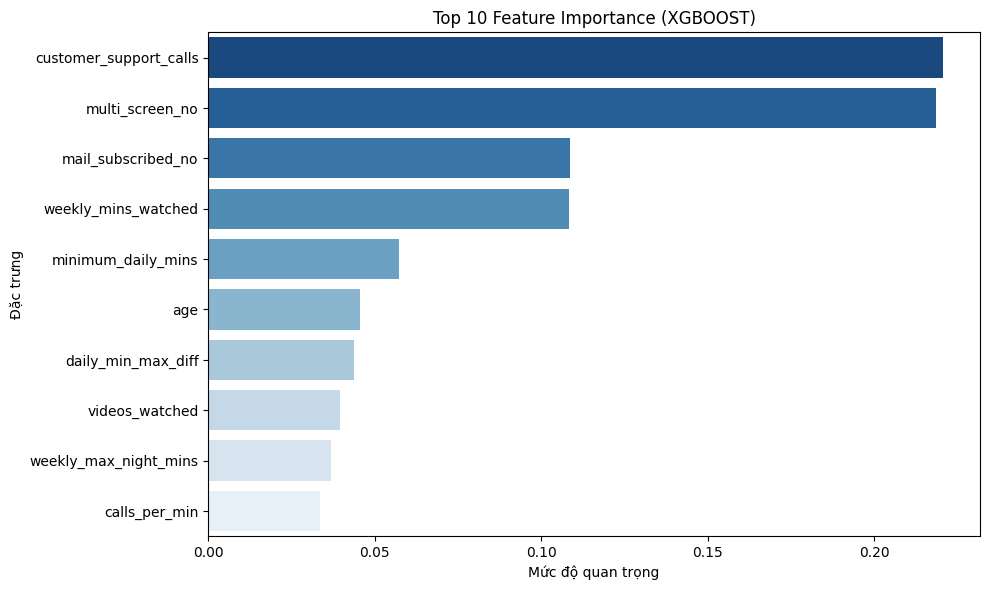

In [133]:
# --- 8. GIẢI THÍCH MÔ HÌNH (FEATURE IMPORTANCE) ---
print(f"\nTop 10 biến quan trọng nhất (XGBOOST):")
# 1. Lấy tên đặc trưng từ Preprocessor (dùng lại preprocessor_rf vì cấu trúc giống nhau)
preprocessor_xgb = best_xgb_model.named_steps['preprocessor']

# Lấy tên cột sau khi xử lý (bao gồm các cột One-Hot mới sinh ra)
feature_names_xgb = preprocessor_xgb.get_feature_names_out()
# Làm sạch tên cột
clean_feature_names_xgb = [name.replace('num__', '').replace('cat__', '') for name in feature_names_xgb]

# 2. Lấy giá trị quan trọng (Importance) từ model
importances_xgb = best_xgb_model.named_steps['model'].feature_importances_

# 3. Tạo DataFrame
importance_df_xgb = pd.DataFrame({
    'Feature': clean_feature_names_xgb,
    'Importance': importances_xgb
}).sort_values(by='Importance', ascending=False)

# 4. In kết quả Top 10
print(importance_df_xgb.head(10))

# 5. Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df_xgb.head(10),
    palette='Blues_r' # Dùng màu khác để phân biệt với RF
)
plt.title(f'Top 10 Feature Importance (XGBOOST)')
plt.xlabel('Mức độ quan trọng')
plt.ylabel('Đặc trưng')
plt.tight_layout()
plt.show()


--- BẮT ĐẦU PHÂN TÍCH SHAP ---
SHAP: Trực quan hóa Tác động Tổng thể (Summary Plot)...


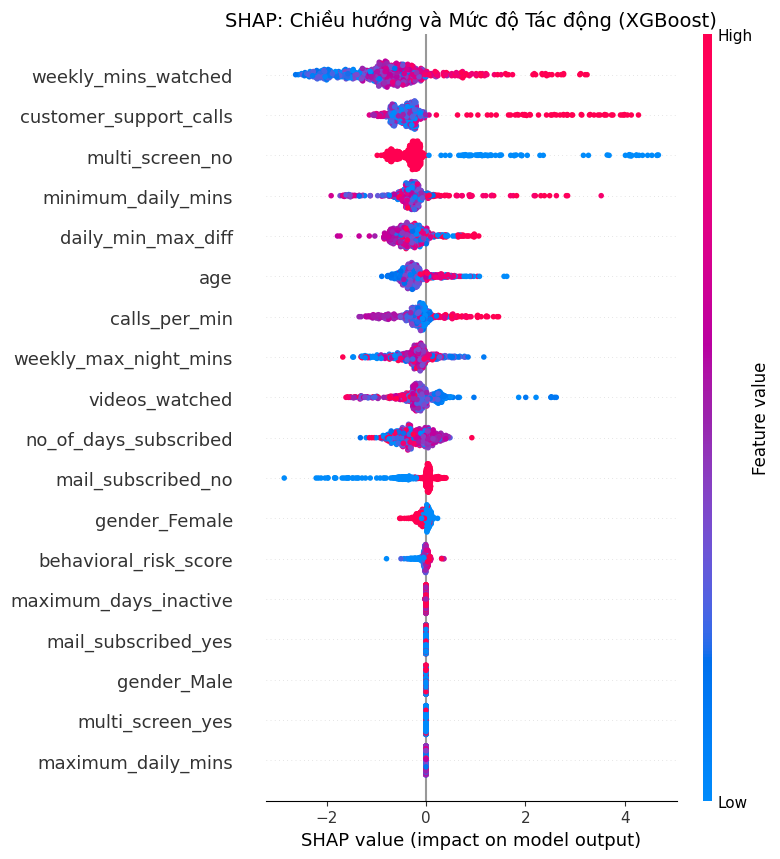


SHAP: Giải thích Cục bộ cho Top 3 Khách hàng Rủi ro Nhất...
   Khách hàng #1 (ID gốc: 314) - P(Churn) = 0.998


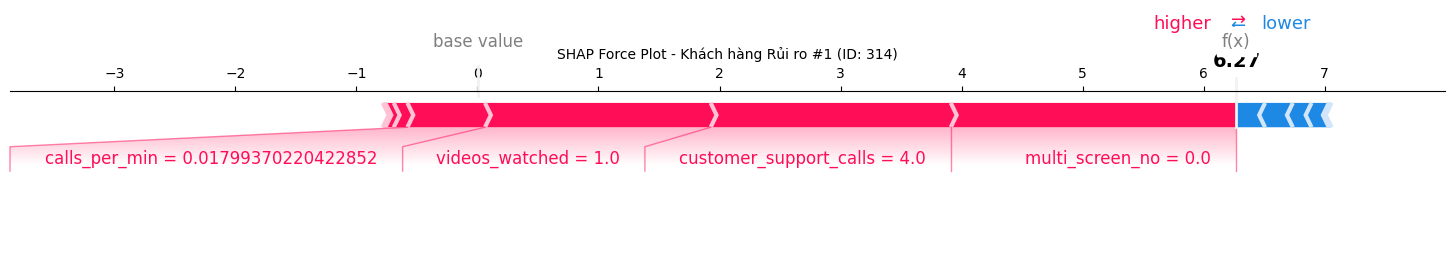

   Khách hàng #2 (ID gốc: 694) - P(Churn) = 0.996


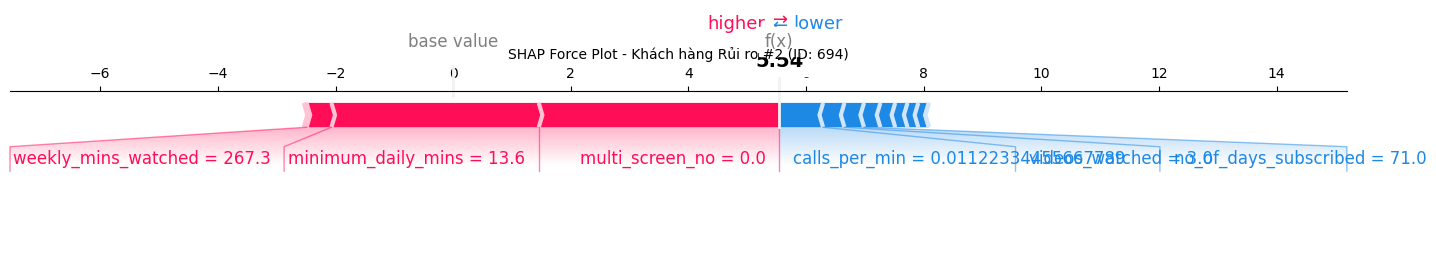

   Khách hàng #3 (ID gốc: 1547) - P(Churn) = 0.994


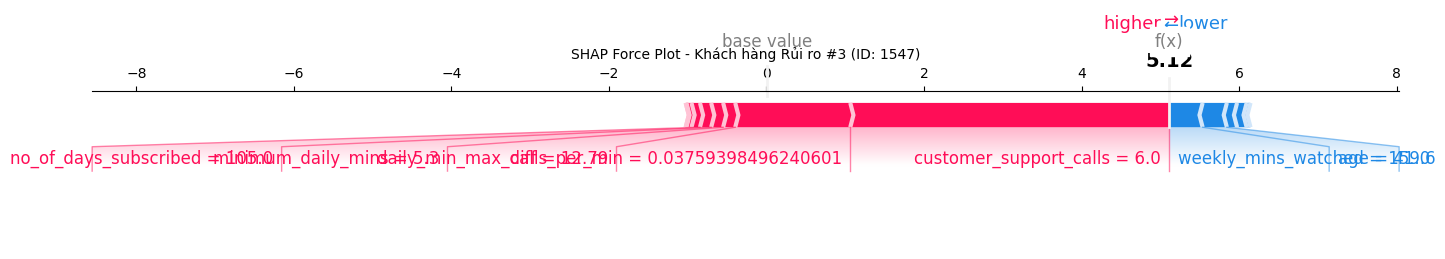


--- KẾT THÚC PHÂN TÍCH SHAP ---


In [135]:
# --- 8.2. BỔ SUNG: PHÂN TÍCH SHAP (GIẢI THÍCH HỘP ĐEN) ---

print("\n--- BẮT ĐẦU PHÂN TÍCH SHAP ---")

# 1. Chuẩn bị dữ liệu Test đã qua tiền xử lý
preprocessor_xgb = best_xgb_model.named_steps['preprocessor']
X_test_processed = preprocessor_xgb.transform(X_test)
X_test_df = pd.DataFrame(X_test_processed, columns=clean_feature_names_xgb)

# 2. Tính toán SHAP values
explainer = shap.TreeExplainer(best_xgb_model.named_steps['model'])
shap_values = explainer.shap_values(X_test_df)

# Lấy xác suất dự đoán Churn
Y_prob_xgb = best_xgb_model.predict_proba(X_test)[:, 1]

# 3. Trực quan hóa Tổng thể (Summary Plot)
print("SHAP: Trực quan hóa Tác động Tổng thể (Summary Plot)...")
# Hiển thị Summary Plot (chiều hướng và mức độ tác động)
shap.summary_plot(shap_values, X_test_df, show=False)
plt.title('SHAP: Chiều hướng và Mức độ Tác động (XGBoost)', fontsize=14)
plt.tight_layout()
plt.show()

# 4. Trực quan hóa Cục bộ (Force Plot) cho Top 3 Rủi ro
print("\nSHAP: Giải thích Cục bộ cho Top 3 Khách hàng Rủi ro Nhất...")
high_risk_indices = np.argsort(Y_prob_xgb)[::-1][:3]

for i, idx in enumerate(high_risk_indices):
    original_index = X_test.index[idx]

    # In thông tin khách hàng
    print(f"   Khách hàng #{i+1} (ID gốc: {original_index}) - P(Churn) = {Y_prob_xgb[idx]:.3f}")

    # Vẽ Force Plot
    base_value = explainer.expected_value
    shap.force_plot(
        base_value,
        shap_values[idx],
        X_test_df.iloc[idx],
        matplotlib=True,
        show=False,
        # Giảm fontsize để tên biến không bị cắt
        text_rotation=0,
        figsize=(15, 3)
    )
    plt.title(f'SHAP Force Plot - Khách hàng Rủi ro #{i+1} (ID: {original_index})', fontsize=10)
    plt.tight_layout()
    plt.show()

print("\n--- KẾT THÚC PHÂN TÍCH SHAP ---")